In [125]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,  auc, accuracy_score, roc_auc_score, roc_curve, confusion_matrix

from feature_engine.outliers import OutlierTrimmer

RAND = 10

# 1.Импорт данных и основные статистики по датасету

### Описание полей:

person_age - Возраст человека

person_gender - Пол человека

person_education - Уровень высшего образования

person_income - Годовой доход

person_emp_exp - Количество лет трудового стажа

person_home_ownership - Статус владения жильем (аренда, своя собственность, ипотека)

loan_amnt - Запрашиваемая сумма кредита

loan_intent - Цель кредита

loan_int_rate - Процентная ставка по кредиту

loan_percent_income - Сумма кредита в процентах от годового дохода

cb_person_cred_hist_length - Продолжительность кредитной истории в годах

credit_score - Кредитный рейтинг человека

previous_loan_defaults_on_file - Индикатор предыдущих невыплат по кредиту

loan_status (целевая переменная) - Статус одобрения кредита: 1 = одобрено; 0 = отклонено

In [3]:
df = pd.read_csv('loan_data.csv')
df.head(5)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [4]:
print(f'df size: {df.shape}')

df size: (45000, 14)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

непонятно почему person_age типа float64, когда в датасете возраст явно int сделаем его таким

In [7]:
df.person_age = df.person_age.astype('int16') # int 16 т.к. в df есть луди с возрастом 144 года
df.person_age.dtype

dtype('int16')

In [8]:
df.nunique()

person_age                           60
person_gender                         2
person_education                      5
person_income                     33989
person_emp_exp                       63
person_home_ownership                 4
loan_amnt                          4483
loan_intent                           6
loan_int_rate                      1302
loan_percent_income                  64
cb_person_cred_hist_length           29
credit_score                        340
previous_loan_defaults_on_file        2
loan_status                           2
dtype: int64

In [9]:
cat_cols = [c for c in df.columns if df[c].dtype == 'object']
num_cols = [c for c in df.columns if df[c].dtype != 'object']

print(f'categorical columns: {cat_cols}\n')
print(f'numerical colunns: {num_cols}')

categorical columns: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']

numerical colunns: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'loan_status']


df.describe()

In [11]:
df.person_education.unique()

array(['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate'],
      dtype=object)

Master - Магистр

High School - 9 - 12 класс

Bachelor - Бакалавр

Associate - Техникум

Doctorate - Доктор наук

In [13]:
df.loan_intent.unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

Personal - кредит на личные нужды

Education - кредит на обучение

Medical - кредит на лечение

Venture - кредит на риск? гемблинг?

Homeimprovement - кредит на улучшение жилья

Debtconsolidation - кредит на погашение другого долга

# 2.Exploratory data analysis

### Гипотезы

1. Уровень образования повышает возвраст человека, и делает его "хорошим" заемщиком
2. Возраст "хороших" заемщиков смещен в большую сторону в сравнееии с "плохими" заемщиками
3. Доход "хорошиш" заемщиков больше дохода "плохих" и зависит от уровня образования
4. Категориальная переменная previous_loan_defaults_on_file	имеет значительную взаимосвязь с loan_status
5. При большом значении loan_percent_income, вероятно что заемщик является "хорошим"
6. credit_score напрямую связано с loan_status, чем он выше, тем выше вероятность клиента выплатить кредит банку
7. loan_int_rate и loan_amnt коррелируют между собой и положительно влияют на флаг loan_status

## 2.1.Target

In [18]:
# Сразу зададим параметры для графиков 
plt.rc('font', size=12)          # Размер шрифта
plt.rc('axes', titlesize=14)     # Размер заголовка осей
plt.rc('xtick', labelsize=10)    # Размер подписей по оси X
plt.rc('ytick', labelsize=10) # Размер подписей по оси Y

# функция для категориальных величин
def do_categorical_plot(dataframe, column, f_hue=None):

    plt.figure(figsize=(7, 7))
    if not f_hue:
        ax = sns.countplot(x=dataframe[column], hue=dataframe[column], legend=False)
    else:
        ax = sns.countplot(data=dataframe, x=dataframe[column], hue=f_hue)
    total_count = len(dataframe[column])

    for p in ax.patches:
        height = p.get_height()
        percentage = (height / total_count) * 100
        ax.text(p.get_x() + p.get_width() / 2, height * 1.02, f'{percentage:.2f}', ha='center')

    plt.title(f'Соотношение категориальной величины {column}')
    plt.xlabel(column)
    return

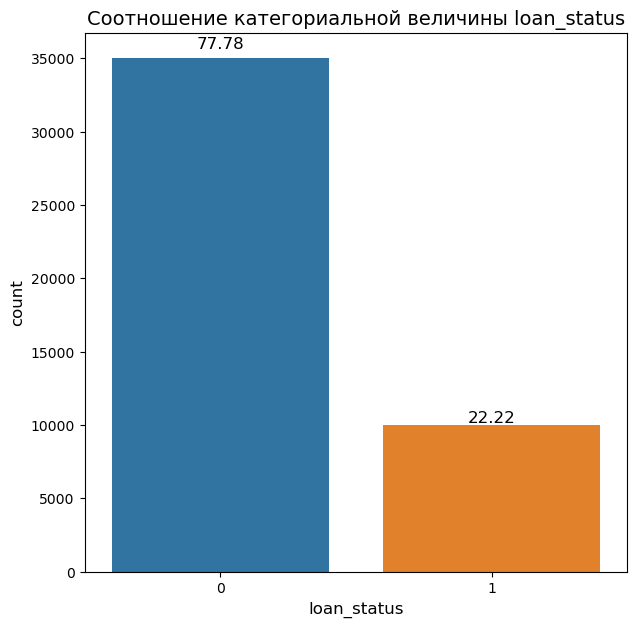

In [19]:
do_categorical_plot(df, 'loan_status')

В датасете есть дисбаланс классов, нужно учесть это

## 2.2. Person_education 

Text(0, 0.5, 'person_age')

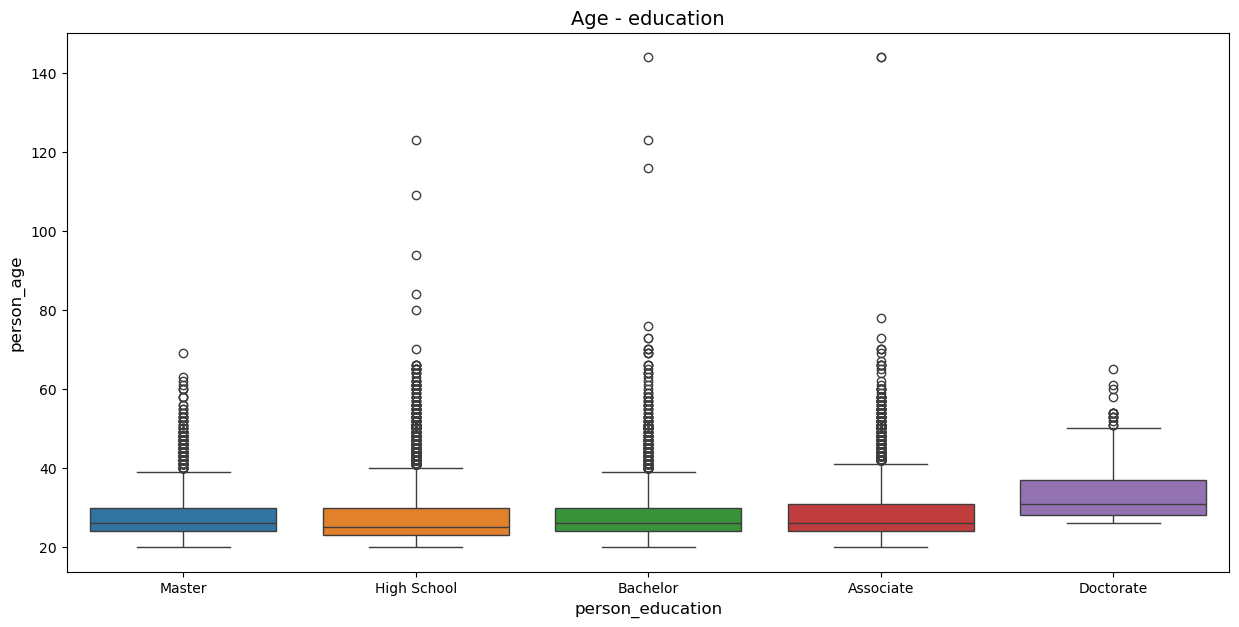

In [22]:
plt.figure(figsize=(15, 7))
sns.boxplot(data=df, x='person_education', y='person_age', hue='person_education', legend=False)

plt.title('Age - education')
plt.xlabel('person_education')
plt.ylabel('person_age')

В датасете присутствует много выбросов в значении возраста

In [24]:
approv_rate = list()
ed_lvl = df.person_education.unique()
for ed in ed_lvl:
    it_ed_lvl = df[df['person_education'] == ed]
    approv_rate.append([ed ,round(len(it_ed_lvl[it_ed_lvl['loan_status'] == 1]) / len(it_ed_lvl), 3) * 100])
approved_loans_ed = pd.DataFrame(approv_rate, columns = ['образование', 'процент одобренных кредитов'])
print(approved_loans_ed)

   образование  процент одобренных кредитов
0       Master                         21.8
1  High School                         22.3
2     Bachelor                         22.5
3    Associate                         22.0
4    Doctorate                         22.9


разные уровни образования практически не влияют на процент одобрения кредита

Text(0.5, 0, 'person_education')

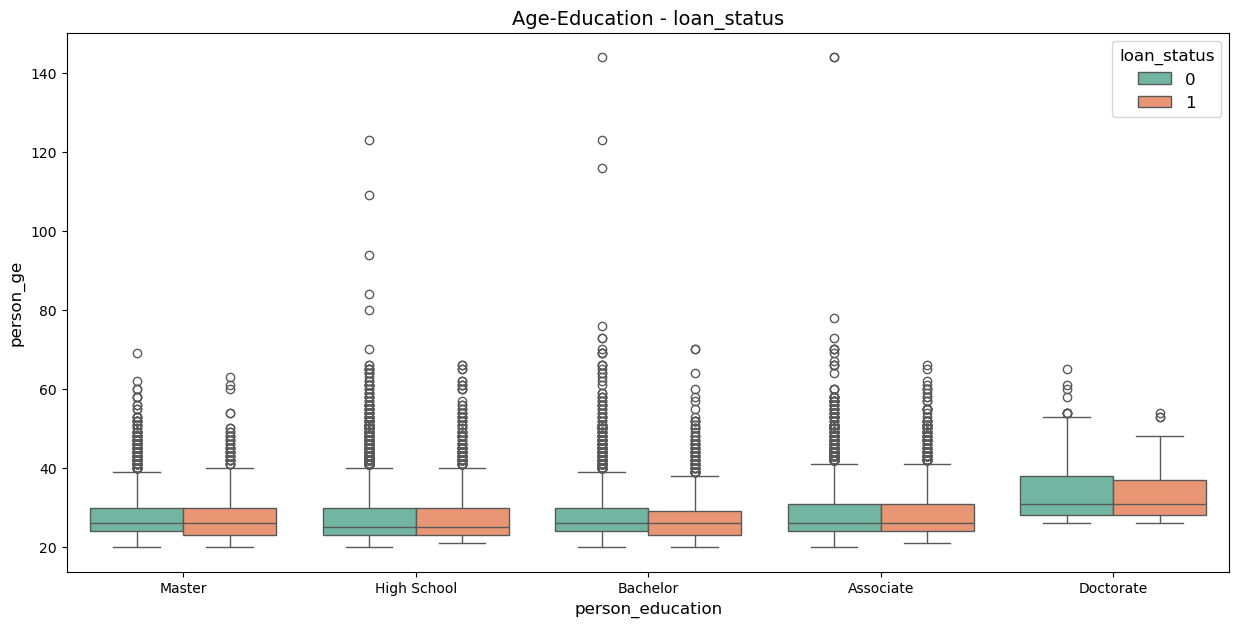

In [26]:
plt.figure(figsize=(15, 7))

sns.boxplot(data=df, x='person_education', y='person_age', palette='Set2', hue='loan_status')

plt.title('Age-Education - loan_status')
plt.ylabel("person_ge")
plt.xlabel("person_education")

то же видим и на графике

## 2.3. Person_age

In [29]:
print(f'|person_age-loan_status mean|\n{df.groupby('loan_status')['person_age'].mean()}',
     f'|person_age-loan_status median|\n{df.groupby('loan_status')['person_age'].median()}',
     f'|person_age-loan_status moda|\n{df.groupby('loan_status')['person_age'].apply(lambda x: x.value_counts().index[0])}',
      sep='\n-------------------------\n')


|person_age-loan_status mean|
loan_status
0    27.833571
1    27.521300
Name: person_age, dtype: float64
-------------------------
|person_age-loan_status median|
loan_status
0    26.0
1    26.0
Name: person_age, dtype: float64
-------------------------
|person_age-loan_status moda|
loan_status
0    23
1    23
Name: person_age, dtype: int16


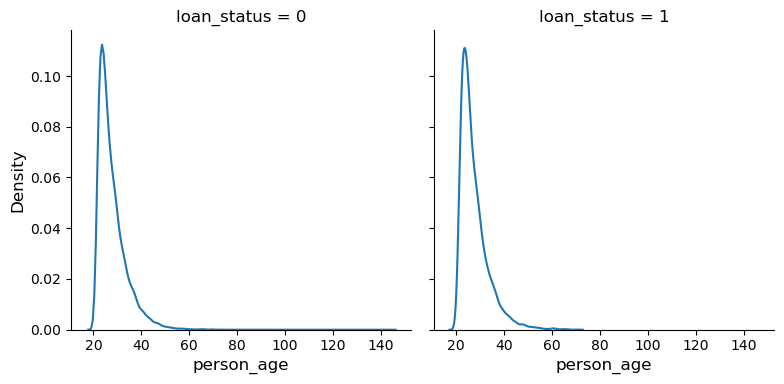

In [30]:
g = sns.FacetGrid(df, col="loan_status", height=4)
g.map(sns.kdeplot, "person_age")

Из знаний и графиков видно - что распределения для "плохих" и "хороших" заемщиков идентичы, к тому же распределение возраста выглядит достаточно не нормально, возможно его нужно нормализировать

## 2.4. Person_income

Text(0.5, 1.0, 'person_age - loan_status')

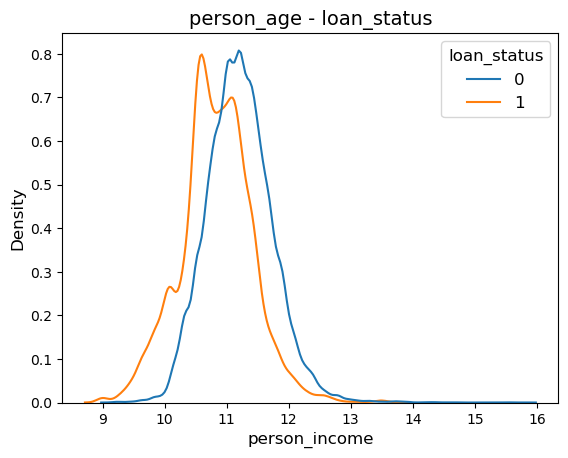

In [33]:
df_income = df.copy()
df_income.person_income = np.log(df_income.person_income + 1)
sns.kdeplot(data=df_income, x='person_income', hue='loan_status', common_norm=False)
plt.title('person_age - loan_status')

In [34]:
df.groupby('loan_status').person_income.mean()

loan_status
0    86157.040743
1    59886.096900
Name: person_income, dtype: float64

для нормальзации графика дохода помогает логарифмирование, удивительно, но банк больше предпочитает выдавать кредиты людям с меньшим доходом, возможно они более релевантны при начислении процентов

Text(0.5, 1.0, 'person_education - person_income')

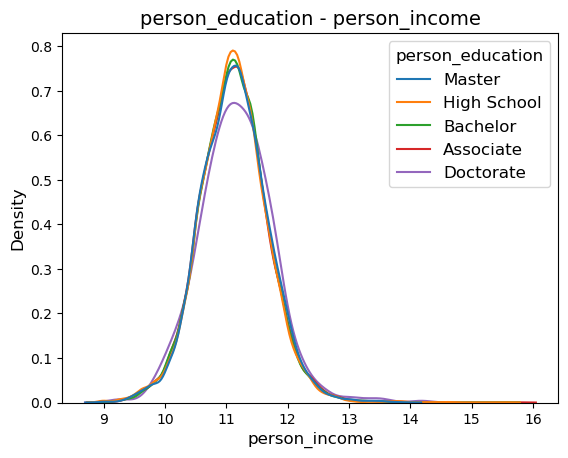

In [36]:
sns.kdeplot(data=df_income, x='person_income', hue='person_education', common_norm=False)
plt.title('person_education - person_income')

доход не зависит от образования

## 2.5. Previous_loan_defaults_on_file

Text(0.5, 1.0, 'loan_defaults - loan_status')

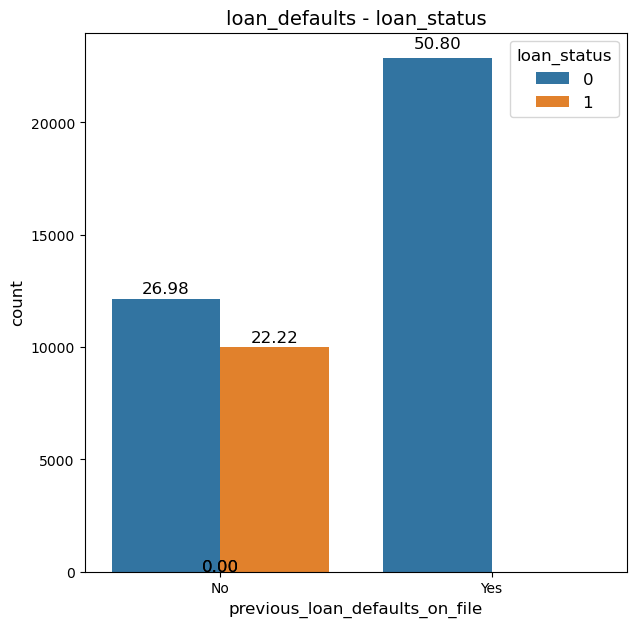

In [39]:
do_categorical_plot(df, 'previous_loan_defaults_on_file', 'loan_status')
plt.title('loan_defaults - loan_status')

кредиты вообще не выдаются людям с не выплатами по прошлым кредитам

## 2.6. loan_person_income

Text(0.5, 1.0, 'loan_percent - loan_status')

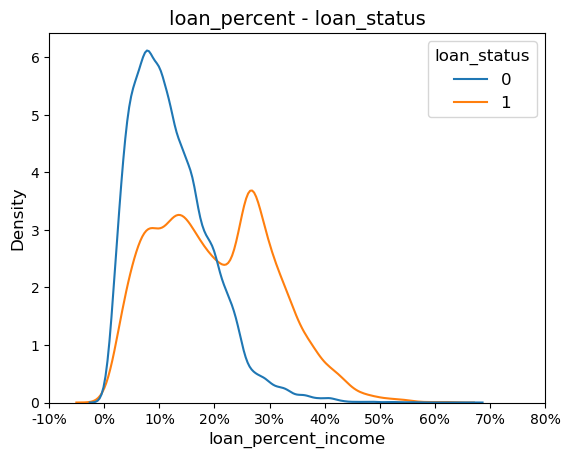

In [42]:
sns.kdeplot(data=df, x='loan_percent_income', hue='loan_status', common_norm=False)
current_ticks = plt.xticks()[0]

new_labels = [f"{int(tick * 100)}%" for tick in current_ticks]

plt.xticks(current_ticks, new_labels)
plt.title('loan_percent - loan_status')

чем больше отношение к годовой зарплате, тем он более привлекателен для кредиторов

In [44]:
## Loan_int_rate

Text(0.5, 1.0, 'loan_int_rate - loan_status')

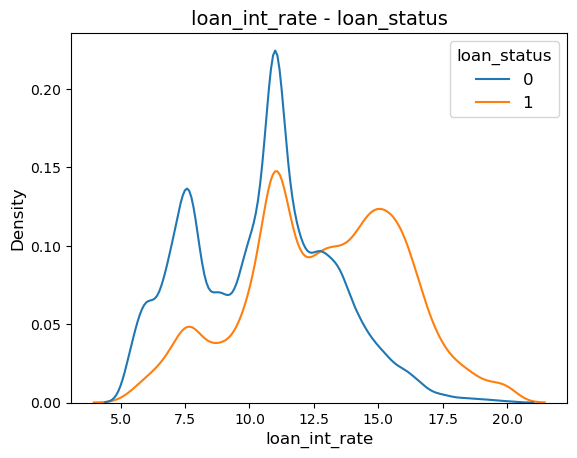

In [45]:
sns.kdeplot(data=df, x='loan_int_rate', hue='loan_status', common_norm=False)
plt.title('loan_int_rate - loan_status')

In [46]:
df.groupby('loan_status').loan_int_rate.mean()

loan_status
0    10.477981
1    12.856794
Name: loan_int_rate, dtype: float64

In [47]:
df.groupby('loan_status').loan_int_rate.median()

loan_status
0    10.85
1    12.98
Name: loan_int_rate, dtype: float64

у "хороших" заемщиков больше процент по кредиту

## 2.7. Credit_score

Text(0.5, 1.0, 'credit_score - loan_status')

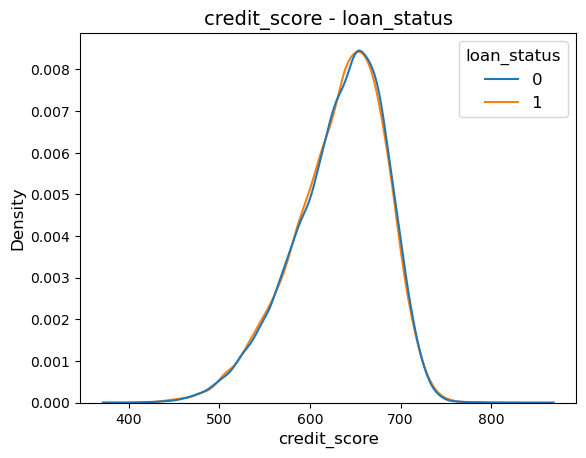

In [50]:
sns.kdeplot(data=df, x='credit_score', hue='loan_status', common_norm=False)
plt.title('credit_score - loan_status')

# 3 Feature engineeering

In [58]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [60]:
# снова переопределим качественные и количественные переменные
cat_cols = [c for c in df.columns if df[c].dtype == 'object'] 
num_cols = [c for c in df.columns if df[c].dtype != 'object']
num_cols.remove('loan_status')

Text(0.5, 0.98, 'Histogram of varios features')

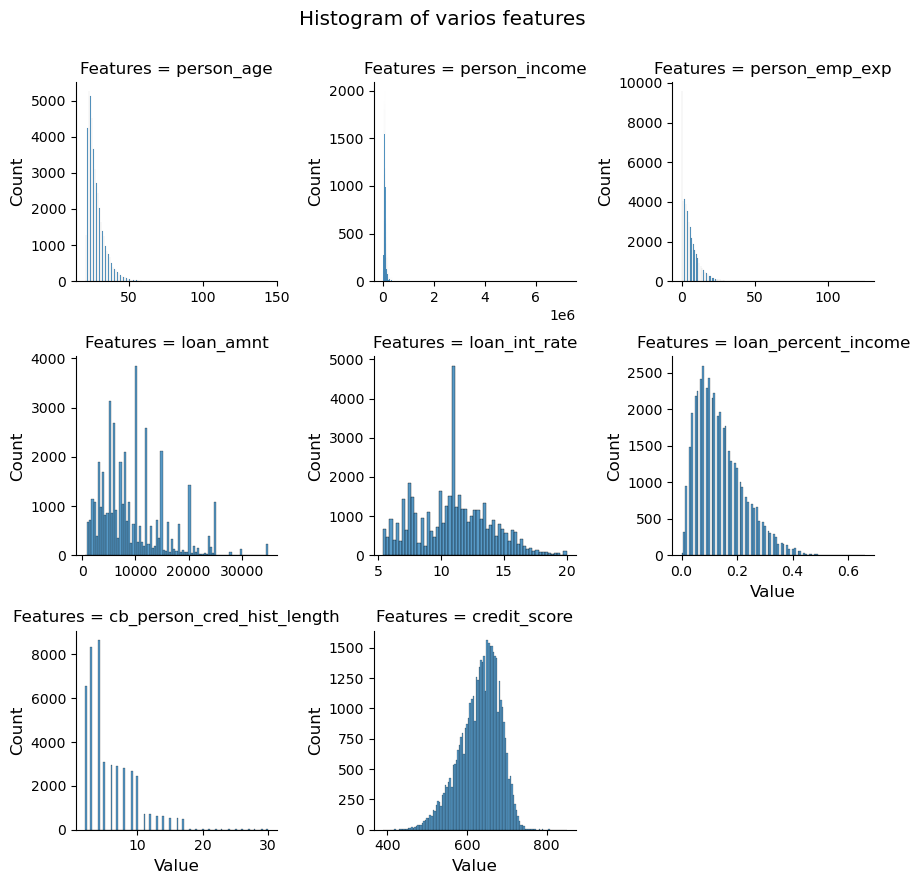

In [62]:
numeric_features = df[num_cols]

numeric_features = df[num_cols].melt(var_name='Features', value_name='Value')

ax = sns.FacetGrid(data=numeric_features, col='Features',
                  col_wrap=3, sharex=False, sharey=False)

ax = ax.map(sns.histplot, 'Value')

plt.subplots_adjust(top=0.9)
ax.fig.suptitle("Histogram of varios features")

In [63]:
for i in ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate']:
    df[i] = np.log(df[i] + 1)

Text(0.5, 0.98, 'Histogram of varios features')

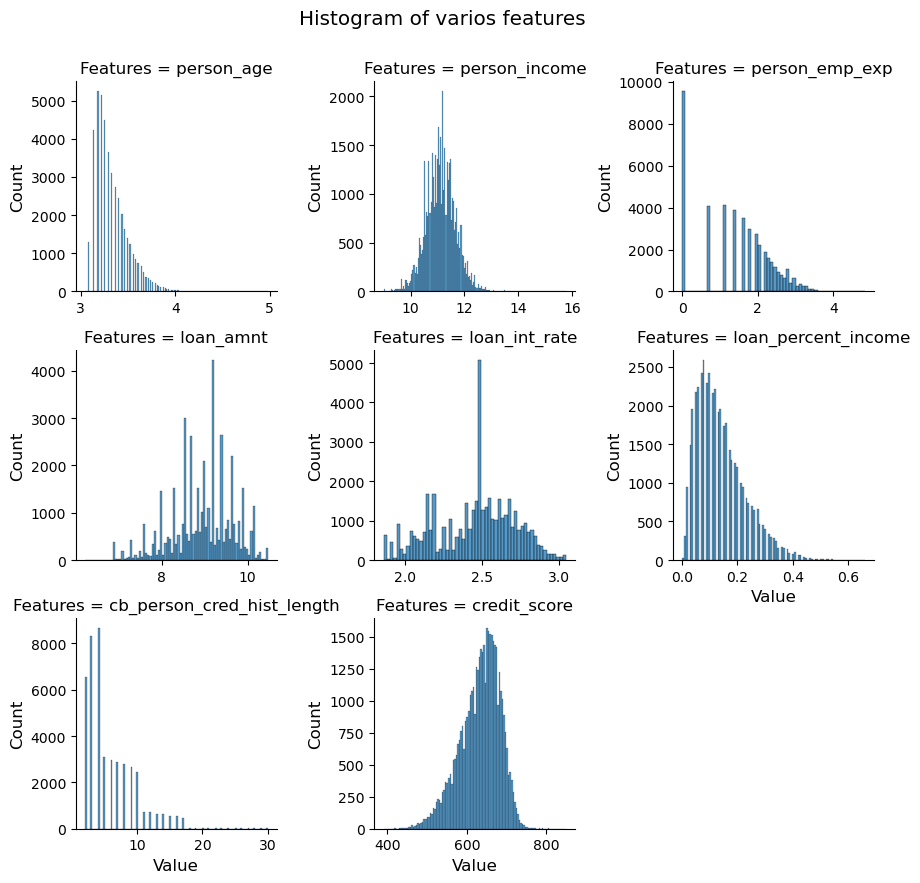

In [64]:
numeric_features = df[num_cols]

numeric_features = df[num_cols].melt(var_name='Features', value_name='Value')

ax = sns.FacetGrid(data=numeric_features, col='Features',
                  col_wrap=3, sharex=False, sharey=False)

ax = ax.map(sns.histplot, 'Value')

plt.subplots_adjust(top=0.9)
ax.fig.suptitle("Histogram of varios features")

## 4 Baseline

In [69]:
df['person_gender'] = df['person_gender'].replace({'male': 0, 'female': 1})
df['person_home_ownership'] = df['person_home_ownership'].replace({'RENT': 0, 'OWN': 1, 'MORTGAGE': 2, 'OTHER': 3})
df['loan_intent'] = df['loan_intent'].replace({'PERSONAL': 0, 'EDUCATION': 1, 'MEDICAL': 2, 'VENTURE': 3, 'HOMEIMPROVEMENT': 4, 'DEBTCONSOLIDATION': 5})
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].replace({'No': 0, 'Yes': 1})
df['person_education'] = df['person_education'].replace({'High School': 0, 'Associate': 1, 'Bachelor': 2, 'Master': 3, 'Doctorate': 4})

In [67]:
trimmer = OutlierTrimmer(capping_method='iqr', tail='right',
                        variables= ['person_age',
       'person_emp_exp', 'loan_amnt',
       'loan_intent', 'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length', 'credit_score',
       ])

df2 = trimmer.fit_transform(df)

Text(0.5, 1.0, 'Correlation Matrix')

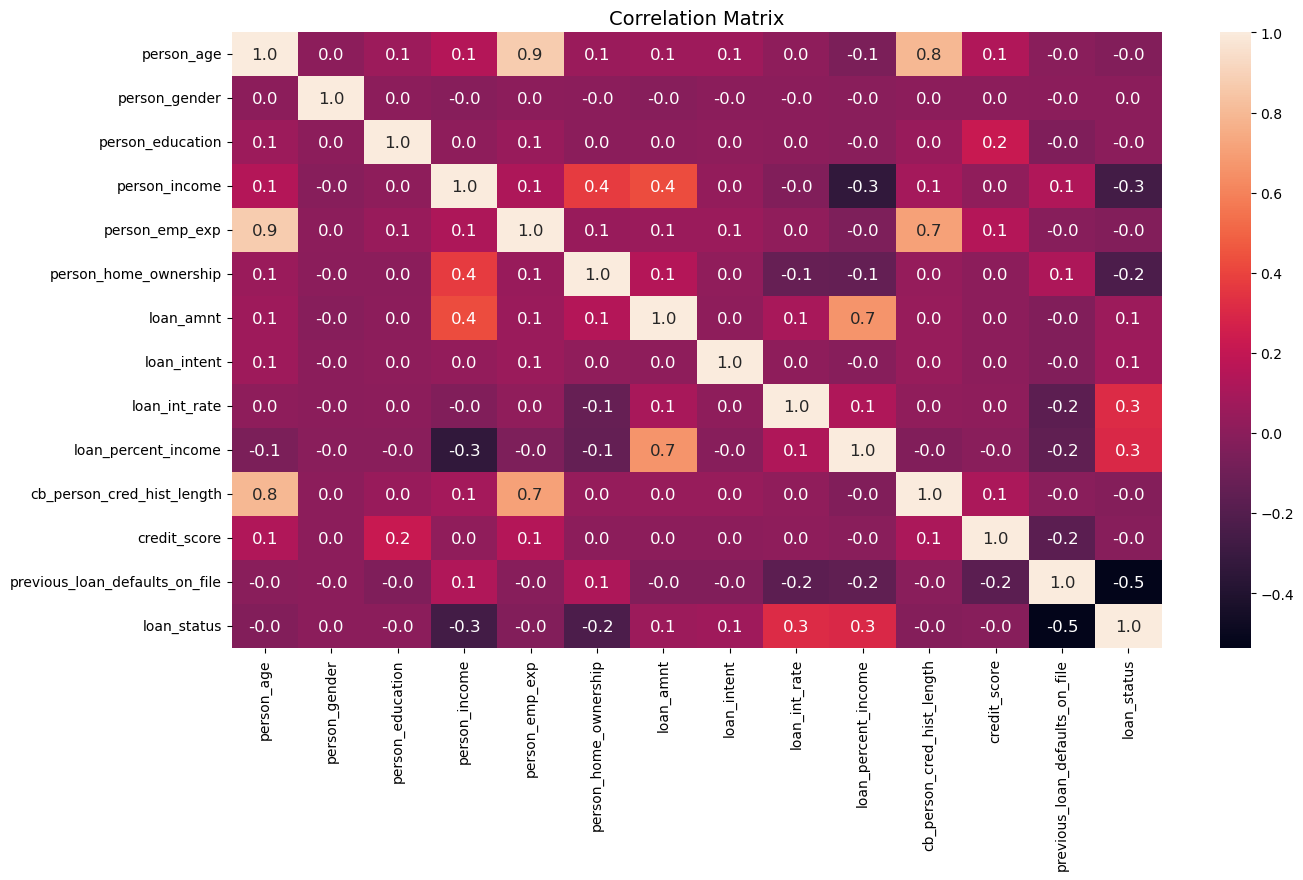

In [87]:
plt.figure(figsize=(15, 8))
corr_mat = df2.corr(method='spearman')
sns.heatmap(data=corr_mat, annot=True, fmt='.1f')
plt.title('Correlation Matrix')

In [93]:
threshold = 0.1
high_corr_param = corr_mat.index[abs(corr_mat["loan_status"]) > threshold].tolist()
high_corr_param.remove("loan_status")
print(high_corr_param)

['person_income', 'person_home_ownership', 'loan_int_rate', 'loan_percent_income', 'previous_loan_defaults_on_file']


Сильнее всего на loan_status влияет 'person_income', 'person_home_ownership', 'loan_int_rate', 'loan_percent_income', 'previous_loan_defaults_on_file'
Из этих признаков сделаем линейную модель

In [95]:
X_selected = df[high_corr_param]
Y = df['loan_status']

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, Y, test_size=0.2, stratify=Y, shuffle=True, random_state=RAND)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(36000, 5) (36000,) (9000, 5) (9000,)


In [113]:
model = LogisticRegression(max_iter=1000, class_weight="Balanced", random_state=RAND) 
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=10)

In [115]:
y_predict1 = model.predict(X_test)

In [121]:
print(classification_report(y_test, y_predict1))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7020
           1       0.75      0.74      0.74      1980

    accuracy                           0.89      9000
   macro avg       0.84      0.83      0.83      9000
weighted avg       0.89      0.89      0.89      9000

